# LOGO ensemble on `benchset_v1_large_set_a.parquet` + `papers_fe.parquet` — every use case as its own rotation

**Author:** SF — **Branch:** `new-dataset-logo-experiments` — **Status:** not yet run (see
§2's own note). Combines `benchset_v1_large_set_a.parquet`'s rows with `papers_fe.parquet`'s rows into one
training pool — the same combination `run_ensemble_combined` in
`scripts/modal_benchset_v1_ensemble.py` already uses — but instead of that script's single
pooled `StratifiedGroupKFold(5)`, this notebook rotates a full **Leave-One-Group-Out** design
across it, exactly the fold *structure* `10_logo_ensemble.ipynb` built for `papers_fe.parquet`
alone, just over a much larger group universe.

## What "group" means here — confirmed with the project owner, not assumed

The group universe for this rotation is **every distinct `use_case_key` in the combined
pool**: `papers_fe.parquet`'s 6 TIRI research questions *and* every one of `benchset_v1_large_set_a.parquet`'s
own 8 published systematic-review collections — **14 rotations**,
not 6. Each rotation removes exactly one group entirely, trains on everything else, and scores
on the untouched group. This directly answers the project owner's stated question — "how does
our model function differently depending on what use case is left out, and which one is
trained on" — across the full mixed universe of TIRI questions and benchset collections, not
just the original 6.

## What's frozen, and why

No hyperparameter search happens in this notebook. `RF_PARAMS`, `CB_PARAMS`, `META_C`, and
`DECISION_THRESHOLD` are imported directly from `scripts/modal_benchset_v1_ensemble.py`, which
copies them verbatim from `08_ensemble_pooled.ipynb`'s own §5 tuning catalog — the same values
`10_logo_ensemble.ipynb` and the companion (non-LOGO) `sf_ensemble_benchset_v1_large_set_a.ipynb`
already reuse unchanged. Per `CONTEXT.md` §1: hyperparameter search happens once, centrally —
not re-run per rotation, per dataset, or per notebook.

## Relationship to the other notebooks touching this data

- **`sf_ensemble_benchset_v1_large_set_a.ipynb`** — the companion, non-LOGO notebook. Same training
  file, same combined-with-`papers_fe.parquet` idea, but a single pooled split scored against
  two external files, not a rotation. Both notebooks exist side by side; this one is additive,
  not a replacement.
- **`10_logo_ensemble.ipynb`** — the LOGO fold *structure* this notebook reuses (outer
  leave-one-group-out, inner `StratifiedGroupKFold(5)` for OOF stacking), but on
  `papers_fe.parquet` alone and only 6 rotations.
- **`sf_ensemble_benchset_v1_large_set_b_logo.ipynb`** — the direct sibling,
  identical design, trained on `benchset_v1_large_set_b.parquet` instead.
  **Not compared against this notebook** — per the project owner's explicit choice, hypothesis
  testing here stays within this notebook's own 14 rotations.

## Feature columns: the common intersection, not `08`'s exact list

Same constraint as the companion notebook: `benchset_v1_large_set_a.parquet` doesn't carry `papers_fe.parquet`'s
Qwen3-Embedding-8B block, `has_abstract`, or `lex_has_exclude_terms`; `papers_fe.parquet`
doesn't carry benchset_v1's `cos_briefpre_*`/`rank_cos_briefpre_*` columns.
`scripts/modal_benchset_v1_ensemble.py`'s `NON_EMBEDDING_FEATURE_COLS` is the common
intersection, confirmed with the project owner — used identically here.

## Why Modal, and what "not yet run" means

`benchset_v1_large_set_a.parquet` alone is tens of thousands of rows by ~4,600 columns; combined with
`papers_fe.parquet` that's the training pool for each of 14 rotations, each fitting
CatBoost + RandomForest + LogisticRegression five times over (inner OOF) plus one final refit.
This is far past what fits comfortably on a laptop — every fit in this notebook routes through
`scripts/modal_benchset_v1_ensemble.py::run_ensemble_combined_logo` on Modal (app
`tiri-benchset-v1-ensemble`, volume `tiri-benchset-v1-data`), one call per rotation. **This
notebook has not been executed** — see §2 below for the exact setup steps and the cost/time
tradeoff before running it for real.

## What "train / validation / test" mean, per rotation

Identical to `10_logo_ensemble.ipynb`'s own definitions, just over the combined pool:

- **train** — every base model + the meta-learner, refit once on the entire `dev_pool`
  (everything except the held-out group), scored back on `dev_pool` itself (optimistic,
  in-sample).
- **validation** — a fresh inner `StratifiedGroupKFold(5)` inside `dev_pool` gives
  leakage-safe out-of-fold meta-level predictions, reported mean ± std across the 5 folds.
- **test** — the refit-on-`dev_pool` ensemble, scored on the untouched held-out group — the
  number that actually answers this notebook's question.

All three stages, at every rotation, report **precision, recall, F2, and AUC** — per the
project owner's explicit instruction — at the same fixed, frozen `DECISION_THRESHOLD`.

## Structure

(1) the 14-group universe for this training file; (2) fetch (or fit, on first run)
every rotation via Modal, with incremental per-rotation caching; (3) hyperparameter catalog
and meta-learner coefficients across rotations; (4) per-rotation precision/recall/F2/AUC,
train → validation → test; (5) train → validation → test overview, overall and split by group
origin; (6) test-stage metrics by rotation, colored by origin; (7) hypothesis tests — omnibus +
Bonferroni-corrected pairwise bootstrap, for both F2 and AUC, across all 14
rotations; (8) findings; (9) scope & limitations.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Parameters

`TRAIN_FILE` is this notebook's own training file; `MODAL_APP_NAME`/`MODAL_FUNCTION_NAME`
identify the deployed Modal function that runs one LOGO rotation. Every hyperparameter is
imported from `scripts/modal_benchset_v1_ensemble.py` — the single source of truth this
notebook, its companion, and `10_logo_ensemble.ipynb`'s own values all trace back to.
`CACHE_PATH` holds the full list of per-rotation results once fetched, keyed by
`holdout_group`, so re-running this notebook doesn't re-trigger paid Modal jobs for rotations
already completed — only missing ones (or all of them, if `FORCE_REFIT=True`) are fetched.

In [2]:
SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

from modal_benchset_v1_ensemble import (
    APP_NAME as MODAL_APP_NAME,
    CB_PARAMS,
    DECISION_THRESHOLD,
    META_C,
    NON_EMBEDDING_FEATURE_COLS,
    PCA_N_COMPONENTS,
    RF_PARAMS,
    list_logo_groups,
)

MODAL_FUNCTION_NAME = "run_ensemble_combined_logo"
TRAIN_FILE = "benchset_v1_large_set_a.parquet"

REPORTS_DIR = Path("../../reports").resolve()
CACHE_PATH = REPORTS_DIR / f"sf_ensemble_{Path(TRAIN_FILE).stem}_plus_papers_fe_logo.json"
FORCE_REFIT = False  # set True to force every rotation to re-fit on Modal, even if cached

N_BOOT = 2000       # bootstrap resamples for every hypothesis test below
ALPHA = 0.05
RANDOM_STATE = 0

print("Frozen hyperparameters (imported from scripts/modal_benchset_v1_ensemble.py, not re-tuned here):")
for name, val in [("RF_PARAMS", RF_PARAMS), ("CB_PARAMS", CB_PARAMS), ("META_C", META_C),
                   ("DECISION_THRESHOLD", DECISION_THRESHOLD), ("PCA_N_COMPONENTS", PCA_N_COMPONENTS),
                   ("n_non_embedding_features", len(NON_EMBEDDING_FEATURE_COLS))]:
    print(f"  {name}: {val}")

Frozen hyperparameters (imported from scripts/modal_benchset_v1_ensemble.py, not re-tuned here):
  RF_PARAMS: {'n_estimators': 527, 'max_depth': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}
  CB_PARAMS: {'depth': 6, 'learning_rate': 0.06119889729184578, 'l2_leaf_reg': 7.474245667651606, 'iterations': 656}
  META_C: 0.1
  DECISION_THRESHOLD: 0.2
  PCA_N_COMPONENTS: 50
  n_non_embedding_features: 29


## 1. The LOGO group universe for this training file

`list_logo_groups` reads only the `use_case_key` column of `papers_fe.parquet` and
`benchset_v1_large_set_a.parquet` locally — no Modal call, no cost — so the exact rotation list is known before
anything is fetched.

In [3]:
groups = list_logo_groups(TRAIN_FILE)
papers_fe_path = Path("../../data/processed/papers_fe.parquet").resolve()
fe_groups = set(pd.read_parquet(papers_fe_path, columns=["use_case_key"])["use_case_key"].unique())

group_table = pd.DataFrame({
    "use_case_key": groups,
    "origin": ["papers_fe (TIRI use case)" if g in fe_groups else TRAIN_FILE for g in groups],
}).sort_values(["origin", "use_case_key"]).reset_index(drop=True)

print(f"{len(groups)} LOGO rotations for {TRAIN_FILE} combined with papers_fe.parquet:")
display(group_table)
n_fe = group_table["origin"].eq("papers_fe (TIRI use case)").sum()
print(f"\n{n_fe} from papers_fe.parquet, {len(group_table) - n_fe} from {TRAIN_FILE}")

14 LOGO rotations for benchset_v1_large_set_a.parquet combined with papers_fe.parquet:


,use_case_key,origin
0,synergy_brouwer_2019,benchset_v1_large_set_a.parquet
1,synergy_leenaars_2020,benchset_v1_large_set_a.parquet
2,synergy_moran_2021,benchset_v1_large_set_a.parquet
3,synergy_muthu_2021,benchset_v1_large_set_a.parquet
4,synergy_nelson_2002,benchset_v1_large_set_a.parquet
5,synergy_sep_2021,benchset_v1_large_set_a.parquet
6,synergy_van_der_valk_2021,benchset_v1_large_set_a.parquet
7,synergy_van_dis_2020,benchset_v1_large_set_a.parquet
8,carbon_capture,papers_fe (TIRI use case)
9,cement_binders,papers_fe (TIRI use case)



6 from papers_fe.parquet, 8 from benchset_v1_large_set_a.parquet


## 2. Fetch (or fit, on first run) every rotation via Modal

Requires `modal deploy scripts/modal_benchset_v1_ensemble.py` and
`modal run scripts/modal_benchset_v1_ensemble.py::upload_data` to have already run (see this
repo's own setup walkthrough). Each rotation is fetched **independently and cached
immediately** as soon as it completes — if this cell is interrupted partway through,
re-running it only fetches whatever's still missing from `CACHE_PATH`, not the whole set
again. **This is the one cell in this notebook that can spend Modal compute credits on a
fresh run** — everything below only reads `results`. 14 rotations, each fitting
CatBoost/RF/LogReg five times (inner OOF) plus one final refit on tens of thousands of rows —
expect a real first run to take a while; see the setup walkthrough for the parallel-via-`.map()`
alternative (`modal run scripts/modal_benchset_v1_ensemble.py::main_combined_logo`), which
shortens wall-clock (not cost) versus this cell's sequential loop.

In [4]:
if CACHE_PATH.exists():
    cached = {r["holdout_group"]: r for r in json.loads(CACHE_PATH.read_text(encoding="utf-8"))}
else:
    cached = {}

if FORCE_REFIT:
    cached = {}

missing = [g for g in groups if g not in cached]
print(f"{len(cached)}/{len(groups)} rotations already cached at {CACHE_PATH}.")
if missing:
    import modal

    print(f"Fetching {len(missing)} missing rotation(s) from {MODAL_APP_NAME}::{MODAL_FUNCTION_NAME} ...")
    fn = modal.Function.from_name(MODAL_APP_NAME, MODAL_FUNCTION_NAME)
    for idx, g in enumerate(missing, 1):
        print(f"  [{idx}/{len(missing)}] {g} ...", end=" ", flush=True)
        cached[g] = fn.remote(TRAIN_FILE, g)
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        CACHE_PATH.write_text(json.dumps(list(cached.values())), encoding="utf-8")
        print(f"done (test n={cached[g]['test']['n']:,}, auc={cached[g]['test']['auc']:.3f}).")
else:
    print("Nothing to fetch.")

results = [cached[g] for g in groups]
print(f"\n{len(results)}/{len(groups)} rotations available.")

14/14 rotations already cached at C:\Users\fossi\Desktop\Bootcamp\TIRI---The-Data-science-project\reports\sf_ensemble_benchset_v1_large_set_a_plus_papers_fe_logo.json.
Nothing to fetch.

14/14 rotations available.


In [5]:
for r in results:
    r["test"]["y"] = np.array(r["test"]["y"])
    r["test"]["proba"] = np.array(r["test"]["proba"])

test_predictions = {r["holdout_group"]: (r["test"]["y"], r["test"]["proba"]) for r in results}

print(f"Total rows across all {len(results)} held-out test sets: {sum(r['test']['n'] for r in results):,} "
      f"(should equal the combined pool's total row count, since every row appears as `test` "
      f"in exactly one rotation).")

Total rows across all 14 held-out test sets: 64,077 (should equal the combined pool's total row count, since every row appears as `test` in exactly one rotation).


## 3. Hyperparameter catalog and meta-learner coefficients across rotations

Every value below was fixed before this notebook ran — nothing here chooses or searches over
any of them. The meta-learner's coefficients, however, are refit fresh in every rotation (a
different set of remaining groups each time), so they're summarized as mean ± std across all
rotations rather than shown once.

In [6]:
hyperparam_catalog = pd.DataFrame([
    {"model": "RandomForest", "hyperparameter": "n_estimators", "final_value": RF_PARAMS["n_estimators"], "source": "08_ensemble_pooled.ipynb §5 (Bayesian/Optuna, not re-run here)"},
    {"model": "RandomForest", "hyperparameter": "max_depth", "final_value": RF_PARAMS["max_depth"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "RandomForest", "hyperparameter": "min_samples_leaf", "final_value": RF_PARAMS["min_samples_leaf"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "RandomForest", "hyperparameter": "max_features", "final_value": RF_PARAMS["max_features"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "depth", "final_value": CB_PARAMS["depth"], "source": "08_ensemble_pooled.ipynb §5 (ensemble-role objective)"},
    {"model": "CatBoost", "hyperparameter": "learning_rate", "final_value": round(CB_PARAMS["learning_rate"], 4), "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "l2_leaf_reg", "final_value": round(CB_PARAMS["l2_leaf_reg"], 3), "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "iterations", "final_value": CB_PARAMS["iterations"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "Meta-learner (LogReg)", "hyperparameter": "C", "final_value": META_C, "source": "08_ensemble_pooled.ipynb §6"},
    {"model": "Ensemble (final)", "hyperparameter": "decision_threshold", "final_value": DECISION_THRESHOLD, "source": "08_ensemble_pooled.ipynb §6"},
    {"model": "Preprocessing", "hyperparameter": "PCA_N_COMPONENTS", "final_value": PCA_N_COMPONENTS, "source": "08_ensemble_pooled.ipynb §2 (structural, not tuned)"},
])
display(hyperparam_catalog)

meta_coef_df = pd.DataFrame({r["holdout_group"]: r["meta_coefficients"] for r in results}).T
print("\nMeta-learner coefficients per rotation (rows=held-out group, higher = more trusted by the ensemble):")
display(meta_coef_df.round(3))
print("\nAcross all rotations - mean ± std:")
display(meta_coef_df.agg(["mean", "std"]).round(3))

,model,hyperparameter,final_value,source
0,RandomForest,n_estimators,527,"08_ensemble_pooled.ipynb §5 (Bayesian/Optuna, ..."
1,RandomForest,max_depth,13,08_ensemble_pooled.ipynb §5
2,RandomForest,min_samples_leaf,7,08_ensemble_pooled.ipynb §5
3,RandomForest,max_features,sqrt,08_ensemble_pooled.ipynb §5
4,CatBoost,depth,6,08_ensemble_pooled.ipynb §5 (ensemble-role obj...
5,CatBoost,learning_rate,0.0612,08_ensemble_pooled.ipynb §5
6,CatBoost,l2_leaf_reg,7.474,08_ensemble_pooled.ipynb §5
7,CatBoost,iterations,656,08_ensemble_pooled.ipynb §5
8,Meta-learner (LogReg),C,0.1,08_ensemble_pooled.ipynb §6
9,Ensemble (final),decision_threshold,0.2,08_ensemble_pooled.ipynb §6



Meta-learner coefficients per rotation (rows=held-out group, higher = more trusted by the ensemble):


,catboost,logreg,rf
carbon_capture,2.531,1.300,4.218
cement_binders,2.710,1.008,4.244
ner,2.969,1.000,3.980
soil_microbiome,2.874,1.181,4.006
solar_leo,2.696,1.323,3.920
synergy_brouwer_2019,1.884,0.685,4.668
synergy_leenaars_2020,1.920,1.831,4.500
synergy_moran_2021,1.360,2.846,3.982
synergy_muthu_2021,2.354,1.509,4.322
synergy_nelson_2002,2.532,1.228,4.236



Across all rotations - mean ± std:


,catboost,logreg,rf
mean,2.404,1.303,4.303
std,0.479,0.518,0.376


## 4. Per-rotation results: precision, recall, F2, and AUC — train → validation → test

Per the project owner's explicit instruction, all four metrics are reported at every stage,
for every rotation — not just F2/AUC. `validation_*_mean`/`*_std` are the inner 5-fold OOF
mean ± std; `train`/`test` are single point estimates (in-sample refit / held-out group,
respectively).

In [7]:
def _stage_metrics(d):
    return {"auc": d["auc"], "precision": d["precision"], "recall": d["recall"], "f2": d["f2_at_threshold"]}


rows = []
for r in results:
    val_df = pd.DataFrame(r["validation_rows"])
    train_m = _stage_metrics(r["train_metrics"])
    test_m = _stage_metrics(r["test"])
    row = {
        "holdout_group": r["holdout_group"],
        "origin": "papers_fe" if r["group_origin"] == "papers_fe.parquet" else "benchset_v1",
        "n_dev": r["n_dev"], "n_test": r["n_test"], "test_pos_rate": round(r["test"]["pos_rate"], 4),
    }
    for k, v in train_m.items():
        row[f"train_{k}"] = round(v, 3)
    for k in ["auc", "precision", "recall", "f2"]:
        col = "f2_at_threshold" if k == "f2" else k
        row[f"validation_{k}_mean"] = round(val_df[col].mean(), 3)
        row[f"validation_{k}_std"] = round(val_df[col].std(), 3)
    for k, v in test_m.items():
        row[f"test_{k}"] = round(v, 3)
    rows.append(row)

logo_results = pd.DataFrame(rows).set_index("holdout_group").sort_values(["origin", "test_auc"], ascending=[True, False])
display(logo_results)

,origin,n_dev,n_test,test_pos_rate,train_auc,train_precision,train_recall,train_f2,validation_auc_mean,validation_auc_std,validation_precision_mean,validation_precision_std,validation_recall_mean,validation_recall_std,validation_f2_mean,validation_f2_std,test_auc,test_precision,test_recall,test_f2
holdout_group,,,,,,,,,,,,,,,,,,,,
synergy_brouwer_2019,benchset_v1,26676,37401,0.0017,0.986,0.334,0.997,0.714,0.952,0.003,0.313,0.006,0.951,0.012,0.676,0.009,0.965,0.034,0.758,0.143
synergy_leenaars_2020,benchset_v1,57366,6711,0.0858,0.995,0.269,1.000,0.648,0.982,0.001,0.270,0.028,0.957,0.019,0.633,0.025,0.859,0.098,1.000,0.351
synergy_van_dis_2020,benchset_v1,55139,8938,0.0081,0.996,0.316,1.000,0.698,0.980,0.001,0.301,0.005,0.969,0.009,0.671,0.006,0.818,0.046,0.333,0.148
synergy_van_der_valk_2021,benchset_v1,63367,710,0.1225,0.995,0.293,1.000,0.674,0.979,0.003,0.273,0.019,0.963,0.014,0.639,0.022,0.781,0.207,0.897,0.538
synergy_muthu_2021,benchset_v1,61390,2687,0.1243,0.995,0.300,1.000,0.681,0.982,0.002,0.285,0.005,0.959,0.011,0.651,0.008,0.741,0.300,0.198,0.212
synergy_nelson_2002,benchset_v1,63719,358,0.2235,0.995,0.294,1.000,0.675,0.979,0.002,0.263,0.027,0.963,0.010,0.627,0.029,0.725,0.312,0.738,0.580
synergy_sep_2021,benchset_v1,63807,270,0.1481,0.995,0.291,1.000,0.673,0.980,0.002,0.280,0.006,0.963,0.010,0.648,0.004,0.690,0.268,0.550,0.455
synergy_moran_2021,benchset_v1,58923,5154,0.0215,0.994,0.296,1.000,0.677,0.982,0.002,0.286,0.007,0.970,0.006,0.656,0.006,0.506,0.022,0.108,0.060
cement_binders,papers_fe,63815,262,0.6489,0.995,0.269,1.000,0.648,0.977,0.002,0.252,0.014,0.961,0.013,0.614,0.014,0.878,0.714,1.000,0.926


## 5. Train → validation → test, overall and split by group origin

Same reasoning as `10_logo_ensemble.ipynb` §4: the train→validation gap is ordinary
overfitting to `dev_pool`; the validation→test gap is domain shift to a genuinely unseen
group. Reported once across all 14 rotations, and again split by origin — TIRI use
cases run at 26-77% positive, `benchset_v1_large_set_a.parquet`'s collections run at well under 25% positive (see
§1) — so pooling the two together as one "mean ± std" risks averaging over two very different
regimes rather than describing either one.

All 14 rotations:


,train_auc,validation_auc_mean,test_auc,train_f2,validation_f2_mean,test_f2,train_precision,validation_precision_mean,test_precision,train_recall,validation_recall_mean,test_recall
mean,0.994,0.977,0.747,0.661,0.636,0.546,0.282,0.271,0.347,1.000,0.961,0.756
std,0.002,0.008,0.114,0.028,0.023,0.325,0.026,0.020,0.269,0.001,0.005,0.327



TIRI-origin rotations only:


,train_auc,validation_auc_mean,test_auc,train_f2,validation_f2_mean,test_f2,train_precision,validation_precision_mean,test_precision,train_recall,validation_recall_mean,test_recall
mean,0.994,0.978,0.730,0.635,0.616,0.859,0.258,0.254,0.595,1.0,0.961,1.0
std,0.001,0.001,0.089,0.010,0.010,0.115,0.008,0.008,0.192,0.0,0.001,0.0



benchset_v1_large_set_a.parquet-origin rotations only:


,train_auc,validation_auc_mean,test_auc,train_f2,validation_f2_mean,test_f2,train_precision,validation_precision_mean,test_precision,train_recall,validation_recall_mean,test_recall
mean,0.994,0.977,0.761,0.680,0.650,0.311,0.299,0.284,0.161,1.000,0.962,0.573
std,0.003,0.010,0.134,0.019,0.017,0.198,0.019,0.017,0.124,0.001,0.006,0.330


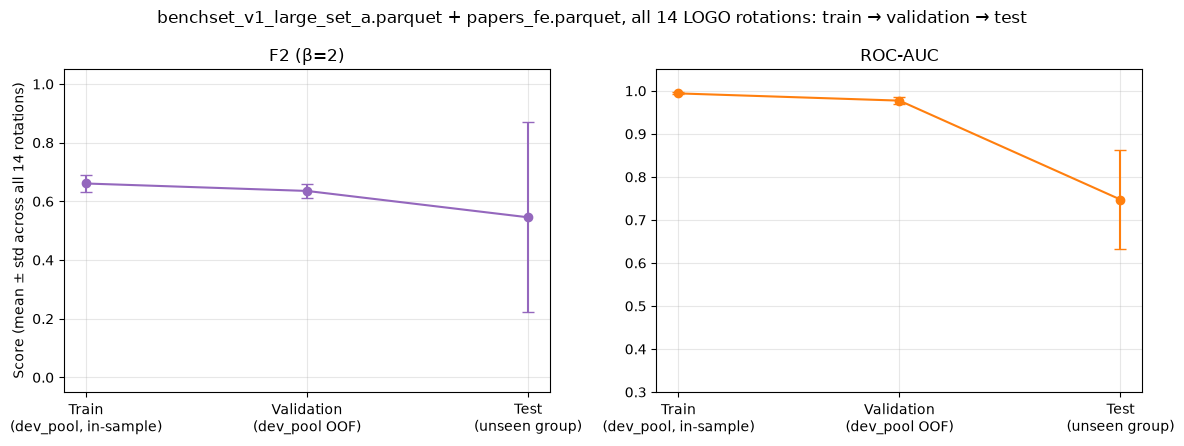

In [8]:
def _overview(df):
    return df[[
        "train_auc", "validation_auc_mean", "test_auc",
        "train_f2", "validation_f2_mean", "test_f2",
        "train_precision", "validation_precision_mean", "test_precision",
        "train_recall", "validation_recall_mean", "test_recall",
    ]].agg(["mean", "std"]).round(3)


print(f"All {len(groups)} rotations:")
display(_overview(logo_results))
print("\nTIRI-origin rotations only:")
display(_overview(logo_results[logo_results["origin"] == "papers_fe"]))
print(f"\n{TRAIN_FILE}-origin rotations only:")
display(_overview(logo_results[logo_results["origin"] != "papers_fe"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
stage_labels = ["Train\n(dev_pool, in-sample)", "Validation\n(dev_pool OOF)", "Test\n(unseen group)"]

for ax, metric, color, title in [(axes[0], "f2", "tab:purple", "F2 (β=2)"), (axes[1], "auc", "tab:orange", "ROC-AUC")]:
    means = [logo_results[f"train_{metric}"].mean(), logo_results[f"validation_{metric}_mean"].mean(), logo_results[f"test_{metric}"].mean()]
    stds = [logo_results[f"train_{metric}"].std(), logo_results[f"validation_{metric}_mean"].std(), logo_results[f"test_{metric}"].std()]
    ax.errorbar(range(3), means, yerr=stds, marker="o", capsize=4, color=color)
    ax.set_xticks(range(3)); ax.set_xticklabels(stage_labels)
    ax.set_title(title)
axes[0].set_ylim(-0.05, 1.05); axes[0].set_ylabel(f"Score (mean ± std across all {len(groups)} rotations)")
axes[1].set_ylim(0.3, 1.05)
fig.suptitle(f"{TRAIN_FILE} + papers_fe.parquet, all {len(groups)} LOGO rotations: train → validation → test")
plt.tight_layout()
plt.show()

## 6. Test-stage metrics by rotation, colored by origin

Bar charts of test-stage F2 and AUC per rotation, colored by whether the held-out group is one
of `papers_fe.parquet`'s 6 TIRI use cases or one of `benchset_v1_large_set_a.parquet`'s own 8
collections.

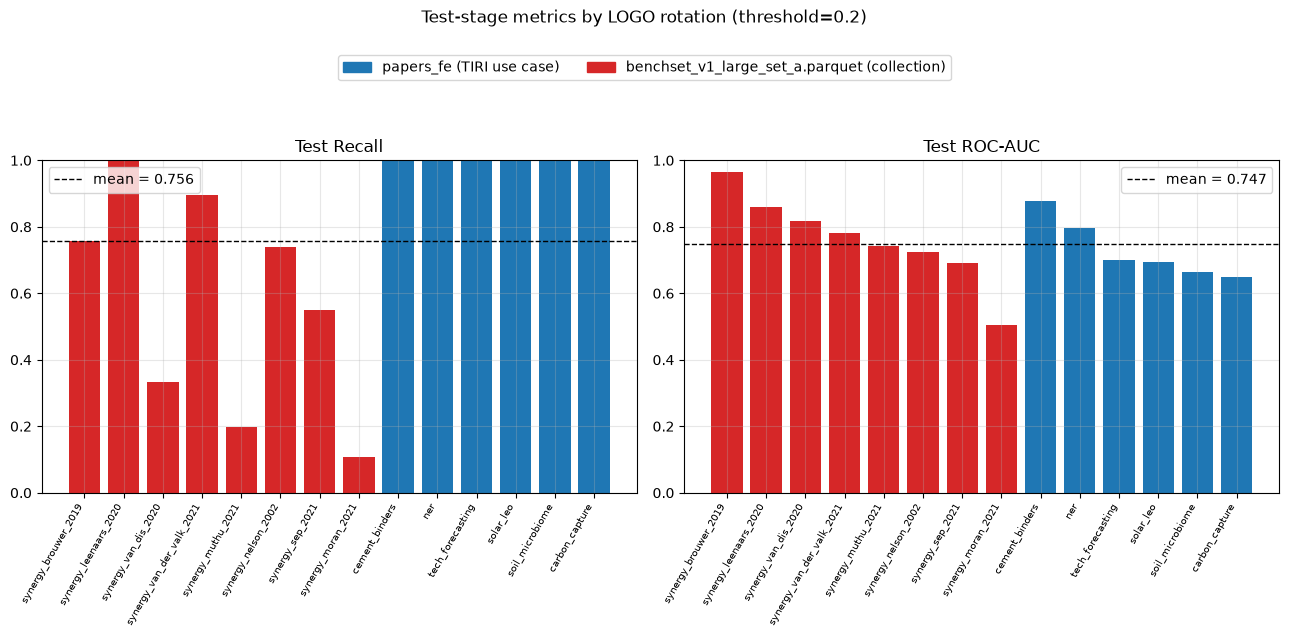

In [13]:
plot_df = logo_results.sort_values("origin")
palette = {"papers_fe": "tab:blue", "benchset_v1": "tab:red"}
bar_colors = [palette[o] for o in plot_df["origin"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
x = np.arange(len(plot_df))
panels = [(axes[0], "test_recall", (0, 1.0), "Test Recall"), (axes[1], "test_auc", (0.0, 1.0), "Test ROC-AUC")]
for ax, metric, ylim, title in panels:
    ax.bar(x, plot_df[metric], color=bar_colors)
    ax.axhline(plot_df[metric].mean(), color="black", linestyle="--", linewidth=1, label=f"mean = {plot_df[metric].mean():.3f}")
    ax.set_xticks(x); ax.set_xticklabels(plot_df.index, rotation=60, ha="right", fontsize=7)
    ax.set_ylim(*ylim); ax.set_title(title)
    ax.legend()

from matplotlib.patches import Patch
handles = [Patch(color=palette["papers_fe"], label="papers_fe (TIRI use case)"),
           Patch(color=palette["benchset_v1"], label=f"{TRAIN_FILE} (collection)")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
fig.suptitle(f"Test-stage metrics by LOGO rotation (threshold={DECISION_THRESHOLD})", y=1.15)
plt.tight_layout()
plt.show()

## 7. Is test performance actually different across rotations? Omnibus + Bonferroni pairwise bootstrap

Same design `10_logo_ensemble.ipynb` §5 uses, generalized from 6 groups to all 14
here, and run for **both F2 and AUC** (the original only tested F2; both are compared here per
the project owner's instruction to use AUC and F2 throughout). Each rotation's test set is a
different, non-overlapping set of rows, so this is an unpaired, independent-groups comparison:

1. Bootstrap each rotation's own test-metric distribution independently (`N_BOOT` resamples of
   that rotation's held-out rows, recomputing the metric each time on the already-computed
   probabilities — no refitting).
2. **Omnibus test first** — a bootstrap analogue of a one-way ANOVA: the observed statistic is
   the between-rotation, n-weighted sum of squares of the 14 point estimates; its
   null distribution recentres each rotation's own bootstrap draws around that rotation's own
   mean (i.e. "how much spread would arise from sampling noise alone if every rotation shared
   one true value").
3. **Pairwise post-hoc only if the omnibus test rejects** — all `C(14,2)=91`
   unpaired comparisons (reusing the same bootstrap draws, no new resampling),
   Bonferroni-corrected (`ALPHA / 91`).

In [10]:
from itertools import combinations
from sklearn.metrics import fbeta_score, roc_auc_score


def metric_at(y, proba, metric, threshold=DECISION_THRESHOLD):
    if metric == "f2":
        return float(fbeta_score(y, (proba >= threshold).astype(int), beta=2, zero_division=0))
    if metric == "auc":
        return float(roc_auc_score(y, proba)) if len(np.unique(y)) > 1 else np.nan
    raise ValueError(metric)


def omnibus_and_pairwise(metric, groups_list, preds, n_boot=N_BOOT, alpha=ALPHA, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    observed = {g: metric_at(*preds[g], metric) for g in groups_list}
    n_g = {g: len(preds[g][0]) for g in groups_list}

    boot = {g: np.empty(n_boot) for g in groups_list}
    for g in groups_list:
        y_g, proba_g = preds[g]
        n = len(y_g)
        for b in range(n_boot):
            idx = rng.randint(0, n, n)
            boot[g][b] = metric_at(y_g[idx], proba_g[idx], metric)

    total_n = sum(n_g.values())
    grand_mean = sum(n_g[g] * observed[g] for g in groups_list) / total_n
    t_obs = sum(n_g[g] * (observed[g] - grand_mean) ** 2 for g in groups_list)

    boot_mean = {g: np.nanmean(boot[g]) for g in groups_list}
    t_null = np.zeros(n_boot)
    for g in groups_list:
        centered = np.nan_to_num(boot[g] - boot_mean[g])
        t_null += n_g[g] * centered ** 2
    omnibus_p = float((t_null >= t_obs).mean())

    pairwise_table = None
    if omnibus_p < alpha:
        pairs = list(combinations(groups_list, 2))
        alpha_corrected = alpha / len(pairs)
        prows = []
        for a, b in pairs:
            diff_obs = observed[a] - observed[b]
            diff_boot = boot[a] - boot[b]
            valid = ~np.isnan(diff_boot)
            ci_lo, ci_hi = np.percentile(diff_boot[valid], [2.5, 97.5])
            p = float(min(2 * min((diff_boot[valid] <= 0).mean(), (diff_boot[valid] >= 0).mean()), 1.0))
            prows.append({
                "group_a": a, "group_b": b, f"{metric}_diff (a-b)": round(diff_obs, 4),
                "ci_low": round(float(ci_lo), 4), "ci_high": round(float(ci_hi), 4),
                "p_value": round(p, 4), "significant (Bonferroni)": p < alpha_corrected,
            })
        pairwise_table = pd.DataFrame(prows).sort_values("p_value")

    return {"observed": observed, "boot": boot, "grand_mean": grand_mean, "t_obs": t_obs,
            "t_null": t_null, "omnibus_p": omnibus_p, "pairwise_table": pairwise_table}


f2_test = omnibus_and_pairwise("f2", groups, test_predictions)
auc_test = omnibus_and_pairwise("auc", groups, test_predictions)

for name, res in [("F2", f2_test), ("AUC", auc_test)]:
    print(f"{name} - grand mean (n-weighted): {res['grand_mean']:.3f}, observed statistic: {res['t_obs']:.4f}, "
          f"null 95th pct: {np.nanpercentile(res['t_null'], 95):.4f}")
    verdict = "REJECT (significant)" if res["omnibus_p"] < ALPHA else "fail to reject (NOT significant)"
    print(f"  Omnibus H0 (all {len(groups)} rotations share one true {name}): p={res['omnibus_p']:.4f} -> {verdict}\n")

F2 - grand mean (n-weighted): 0.191, observed statistic: 1354.9057, null 95th pct: 61.6917
  Omnibus H0 (all 14 rotations share one true F2): p=0.0000 -> REJECT (significant)

AUC - grand mean (n-weighted): 0.876, observed statistic: 1162.1937, null 95th pct: 33.1274
  Omnibus H0 (all 14 rotations share one true AUC): p=0.0000 -> REJECT (significant)



### 7.1 Pairwise post-hoc tables (only populated where the omnibus test above rejected H0)

In [11]:
for name, res in [("F2", f2_test), ("AUC", auc_test)]:
    if res["pairwise_table"] is None:
        print(f"--- {name} pairwise: skipped - omnibus not significant ---\n")
        continue
    n_sig = res["pairwise_table"]["significant (Bonferroni)"].sum()
    print(f"--- {name} pairwise: {len(res['pairwise_table'])} comparisons, {n_sig} significant after Bonferroni correction ---")
    display(res["pairwise_table"])
    print()

--- F2 pairwise: 91 comparisons, 73 significant after Bonferroni correction ---


,group_a,group_b,f2_diff (a-b),ci_low,ci_high,p_value,significant (Bonferroni)
0,carbon_capture,cement_binders,-0.0954,-0.1330,-0.0608,0.000,True
1,carbon_capture,ner,-0.0987,-0.1350,-0.0654,0.000,True
2,carbon_capture,soil_microbiome,0.1893,0.1286,0.2526,0.000,True
3,carbon_capture,solar_leo,-0.1152,-0.1537,-0.0826,0.000,True
4,carbon_capture,synergy_brouwer_2019,0.6870,0.6374,0.7329,0.000,True
5,carbon_capture,synergy_leenaars_2020,0.4791,0.4395,0.5130,0.000,True
6,carbon_capture,synergy_moran_2021,0.7700,0.7192,0.8140,0.000,True
7,carbon_capture,synergy_muthu_2021,0.6184,0.5628,0.6703,0.000,True
8,carbon_capture,synergy_nelson_2002,0.2509,0.1663,0.3345,0.000,True
9,carbon_capture,synergy_sep_2021,0.3759,0.2526,0.5046,0.000,True



--- AUC pairwise: 91 comparisons, 42 significant after Bonferroni correction ---


,group_a,group_b,auc_diff (a-b),ci_low,ci_high,p_value,significant (Bonferroni)
0,carbon_capture,cement_binders,-0.2301,-0.3065,-0.1516,0.000,True
4,carbon_capture,synergy_brouwer_2019,-0.3168,-0.3784,-0.2521,0.000,True
5,carbon_capture,synergy_leenaars_2020,-0.2109,-0.2744,-0.1472,0.000,True
11,carbon_capture,synergy_van_dis_2020,-0.1700,-0.2471,-0.0907,0.000,True
15,cement_binders,solar_leo,0.1835,0.1054,0.2682,0.000,True
14,cement_binders,soil_microbiome,0.2151,0.1362,0.2936,0.000,True
10,carbon_capture,synergy_van_der_valk_2021,-0.1323,-0.2098,-0.0553,0.000,True
16,cement_binders,synergy_brouwer_2019,-0.0867,-0.1354,-0.0439,0.000,True
24,cement_binders,tech_forecasting,0.1797,0.1051,0.2593,0.000,True
27,ner,synergy_brouwer_2019,-0.1692,-0.2292,-0.1106,0.000,True


## 8. Findings

Auto-generated from this run's own numbers where possible, so they can't drift out of sync
with what this notebook actually measured.

In [12]:
print("HARD FINDINGS - generated from this run's own results\n")

print(f"1. Across all {len(groups)} LOGO rotations: mean test AUC "
      f"{logo_results['test_auc'].mean():.3f} ± {logo_results['test_auc'].std():.3f}, "
      f"mean test F2 {logo_results['test_f2'].mean():.3f} ± {logo_results['test_f2'].std():.3f}.")

tiri = logo_results[logo_results["origin"] == "papers_fe"]
bench = logo_results[logo_results["origin"] != "papers_fe"]
print(f"\n2. By origin - TIRI use cases (n={len(tiri)}): test AUC {tiri['test_auc'].mean():.3f} ± {tiri['test_auc'].std():.3f}, "
      f"test F2 {tiri['test_f2'].mean():.3f} ± {tiri['test_f2'].std():.3f}, mean held-out pos_rate {tiri['test_pos_rate'].mean():.3f}.")
print(f"   {TRAIN_FILE} collections (n={len(bench)}): test AUC {bench['test_auc'].mean():.3f} ± {bench['test_auc'].std():.3f}, "
      f"test F2 {bench['test_f2'].mean():.3f} ± {bench['test_f2'].std():.3f}, mean held-out pos_rate {bench['test_pos_rate'].mean():.3f}.")

overfit_gap_f2 = logo_results["train_f2"].mean() - logo_results["validation_f2_mean"].mean()
shift_gap_f2 = logo_results["validation_f2_mean"].mean() - logo_results["test_f2"].mean()
larger = "domain-shift larger" if abs(shift_gap_f2) > abs(overfit_gap_f2) else "overfitting larger"
print(f"\n3. Train -> validation -> test gaps (F2): overfitting gap {overfit_gap_f2:+.3f}, "
      f"domain-shift gap {shift_gap_f2:+.3f} ({larger}).")

f2_verdict = "reject H0" if f2_test["omnibus_p"] < ALPHA else "fail to reject H0"
auc_verdict = "reject H0" if auc_test["omnibus_p"] < ALPHA else "fail to reject H0"
print(f"\n4. Omnibus tests: F2 p={f2_test['omnibus_p']:.4f} ({f2_verdict}); "
      f"AUC p={auc_test['omnibus_p']:.4f} ({auc_verdict}).")

best_g = logo_results["test_auc"].idxmax()
worst_g = logo_results["test_auc"].idxmin()
print(f"\n5. Best test AUC: {best_g} ({logo_results.loc[best_g, 'test_auc']:.3f}, "
      f"origin={logo_results.loc[best_g, 'origin']}, n_test={logo_results.loc[best_g, 'n_test']:,}, "
      f"pos_rate={logo_results.loc[best_g, 'test_pos_rate']:.3f}).")
print(f"   Worst test AUC: {worst_g} ({logo_results.loc[worst_g, 'test_auc']:.3f}, "
      f"origin={logo_results.loc[worst_g, 'origin']}, n_test={logo_results.loc[worst_g, 'n_test']:,}, "
      f"pos_rate={logo_results.loc[worst_g, 'test_pos_rate']:.3f}).")

print(f"\n6. Precision at the frozen threshold, by origin - the cost of a threshold tuned on "
      f"papers_fe.parquet's 26-77%-positive regime: TIRI-origin rotations mean precision "
      f"{tiri['test_precision'].mean():.3f}; {TRAIN_FILE}-origin rotations mean precision "
      f"{bench['test_precision'].mean():.3f}.")

HARD FINDINGS - generated from this run's own results

1. Across all 14 LOGO rotations: mean test AUC 0.747 ± 0.114, mean test F2 0.546 ± 0.325.

2. By origin - TIRI use cases (n=6): test AUC 0.730 ± 0.089, test F2 0.859 ± 0.115, mean held-out pos_rate 0.581.
   benchset_v1_large_set_a.parquet collections (n=8): test AUC 0.761 ± 0.134, test F2 0.311 ± 0.198, mean held-out pos_rate 0.092.

3. Train -> validation -> test gaps (F2): overfitting gap +0.025, domain-shift gap +0.090 (domain-shift larger).

4. Omnibus tests: F2 p=0.0000 (reject H0); AUC p=0.0000 (reject H0).

5. Best test AUC: synergy_brouwer_2019 (0.965, origin=benchset_v1, n_test=37,401, pos_rate=0.002).
   Worst test AUC: synergy_moran_2021 (0.506, origin=benchset_v1, n_test=5,154, pos_rate=0.021).

6. Precision at the frozen threshold, by origin - the cost of a threshold tuned on papers_fe.parquet's 26-77%-positive regime: TIRI-origin rotations mean precision 0.595; benchset_v1_large_set_a.parquet-origin rotations mean pr

## 9. Scope & limitations

- **This is a defaults-selection instrument, not a production estimate** (`CONTEXT.md` §1,
  `10_logo_ensemble.ipynb` §7) — a significant omnibus result says the ensemble's *transfer*
  performance is uneven across this mixed group universe, not anything about a production
  surface.
- **No hyperparameter search happened here, by design** — every fixed value was tuned against
  `papers_fe.parquet`'s pooled split in `08_ensemble_pooled.ipynb`, not against `benchset_v1_large_set_a.parquet`,
  any individual rotation, or this mixed group universe.
- **Group sizes vary enormously** — from 262-37,401 rows across the 14
  groups (see §1/§4), with `benchset_v1_large_set_a.parquet`'s own collections ranging 270-37,401
  rows — so test-stage metrics for the largest collections rest on far more rows, and far more
  stable estimates, than for the smallest TIRI use cases or collections. The bootstrap CIs in
  §7 reflect this per-group, but the plain averages in §5/§6 do not weight for it beyond the
  n-weighting already built into the omnibus statistic.
- **Feature columns are the common intersection across `papers_fe.parquet` and `benchset_v1_large_set_a.parquet`,
  not `08_ensemble_pooled.ipynb`'s exact list** — see this notebook's intro and
  `scripts/modal_benchset_v1_ensemble.py`'s module docstring.
- **Not compared against `sf_ensemble_benchset_v1_large_set_b_logo.ipynb`** —
  per the project owner's explicit choice, hypothesis testing here stays within this notebook's
  own 14 rotations. A cross-notebook comparison would need its own design decision
  (paired on what? unpaired on which surfaces?) that hasn't been made.
- **Bootstrap, not an exact test** — matching this project's existing convention
  (`08_ensemble_pooled.ipynb` §8, `10_logo_ensemble.ipynb` §5), not an oversight.
- **Only one random seed, one set of splits.** `RANDOM_STATE=0` throughout.
- **Modal cost.** §2's fetch loop is the only cell that can trigger fresh (paid) fits, and it
  caches every rotation individually so re-running this notebook after a first successful pass
  costs nothing further.